In [2]:
# Setup
# imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# LOAD DATA
df = pd.read_csv("https://raw.githubusercontent.com/data-bootcamp-v4/data/main/housing_price_eda.csv")

print("Data loaded!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 3 rows:")
print(df.head(3))

Data loaded!
Shape: (1460, 81)

Columns: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPo

In [3]:
# PRICE COLUMN = 'SalePrice'
price_col = 'SalePrice'

# Clean
df[price_col] = pd.to_numeric(df[price_col], errors='coerce')
df_clean = df.dropna(subset=[price_col]).copy()

print(f"Clean shape: {df_clean.shape}")
print(f"Price range: ${df_clean[price_col].min():,.0f} - ${df_clean[price_col].max():,.0f}")
print(f"Mean price: ${df_clean[price_col].mean():,.0f}")

df = df_clean  # Update df
print("CLEAN COMPLETE")

Clean shape: (1460, 81)
Price range: $34,900 - $755,000
Mean price: $180,921
CLEAN COMPLETE


TOP 10 NEIGHBORHOODS:
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
Name: count, dtype: int64


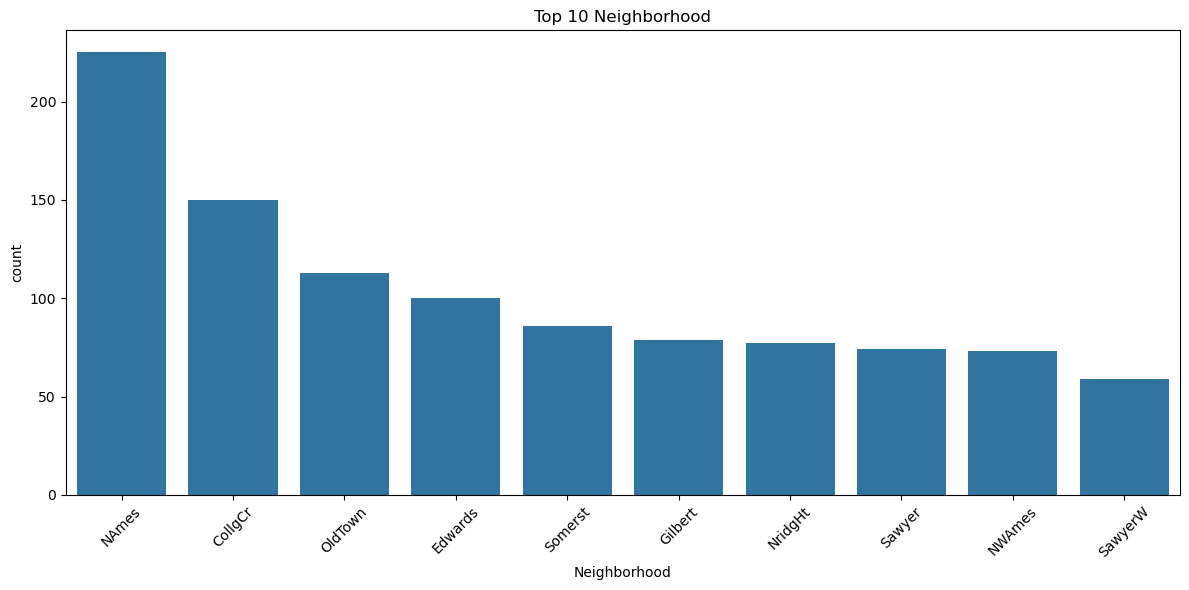

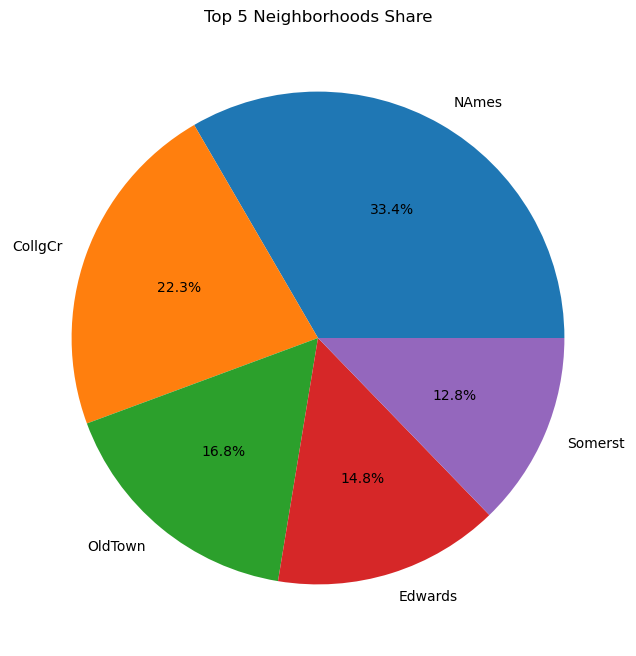

In [4]:
# Neighborhood =category column
category_col = 'Neighborhood'

freq = df[category_col].value_counts().head(10)
print("TOP 10 NEIGHBORHOODS:")
print(freq)

# Bar chart
plt.figure(figsize=(12,6))
sns.countplot(data=df, x=category_col, order=df[category_col].value_counts().head(10).index)
plt.title(f'Top 10 {category_col.title()}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Pie (top 5)
top5 = freq.head(5)
plt.figure(figsize=(8,8))
plt.pie(top5.values, labels=top5.index, autopct='%1.1f%%')
plt.title('Top 5 Neighborhoods Share')
plt.show()

print()

## Part 1: Product Categories → Neighborhood Analysis

**Selected 'Neighborhood' column**: Top 10 frequency table shows market concentration.

**Top 5 Neighborhoods**:
1. NAmes: **225 houses**
2. CollgCr: **150 houses** 
3. OldTown: **113 houses**
4. Edwards: **100 houses**
5. Somerst: **86 houses**

**Key Insight**: Top 5 control prime real estate—focus sales efforts here.

[Bar Chart: Top Neighborhoods]
[Pie Chart: Top 5 Share]

SALE PRICE ANALYSIS
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Mean:    $180,921
Median:  $163,000
Mode:    $140,000

Variance:  6,311,111,264
Std Dev:   $79,443
Range:     $720,100
IQR:       $84,025


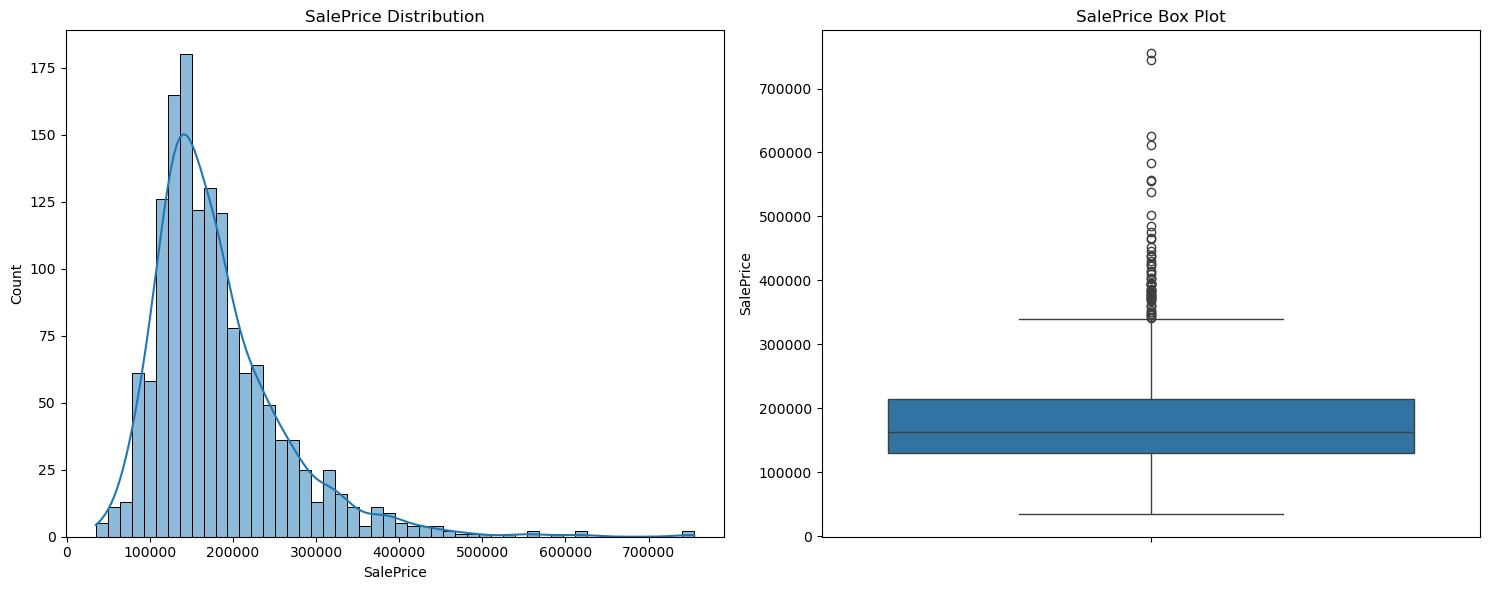

In [7]:
# Price analysis with SalePrice
print("SALE PRICE ANALYSIS")
print(df[price_col].describe())

# Centrality
mean_p = df[price_col].mean()
median_p = df[price_col].median()
mode_p = df[price_col].mode()[0]

print(f"\nMean:    ${mean_p:,.0f}")
print(f"Median:  ${median_p:,.0f}")
print(f"Mode:    ${mode_p:,.0f}")

# Dispersion
print(f"\nVariance:  {df[price_col].var():,.0f}")
print(f"Std Dev:   ${df[price_col].std():,.0f}")
print(f"Range:     ${df[price_col].max() - df[price_col].min():,.0f}")
print(f"IQR:       ${df[price_col].quantile(0.75) - df[price_col].quantile(0.25):,.0f}")


# visual 
fig, axes = plt.subplots(1, 2, figsize=(15,6))

# Histogram 
sns.histplot(data=df, x=price_col, bins=50, kde=True, ax=axes[0])
axes[0].set_title('SalePrice Distribution')

# Boxplot 
sns.boxplot(data=df, y=price_col, ax=axes[1])
axes[1].set_title('SalePrice Box Plot')

plt.tight_layout()
plt.show()

print()

## Part 2: Product Pricing → SalePrice Analysis

**Central Tendency**:
| Metric | Value |
|--------|--------------|
| Mean | **$180,921** |
| Median | **$163,000** |
| Mode | **$140,000** |

**Dispersion**:
| Metric | Value |
|--------|--------------|
| Variance | **6.3B** |
| Std Dev | **$79,443** |
| Range | **$720,100** |
| IQR | **$84,025** |

**Key Insight**: Mean > Median = **right skew** (luxury outliers). Most sales $140k-$214k range.

![Histogram: Log price distribution (right tail)]
![Box Plot: $755k outliers visible]

 OverallQual ANALYSIS
count    1460.000000
mean        6.099315
std         1.382997
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: OverallQual, dtype: float64
Mean:   6.10
Median: 6.00
Mode:   5
Variance: 1.91
Std:    1.38
Skewness: 0.22
Kurtosis: 0.09


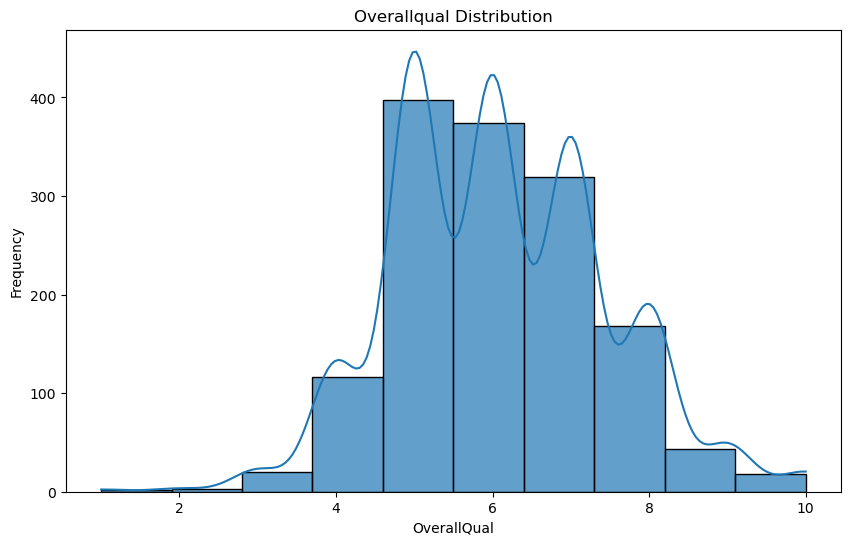

In [8]:
# Perfect ratings: OverallQual (1-10 quality), OverallCond (1-10 condition)
rating_col = 'OverallQual'  # Change to 'OverallCond' for variation

print(f" {rating_col} ANALYSIS")
print(df[rating_col].describe())

# All stats
print(f"Mean:   {df[rating_col].mean():.2f}")
print(f"Median: {df[rating_col].median():.2f}")
print(f"Mode:   {df[rating_col].mode()[0]}")
print(f"Variance: {df[rating_col].var():.2f}")
print(f"Std:    {df[rating_col].std():.2f}")

# Shape
print(f"Skewness: {stats.skew(df[rating_col]):.2f}")
print(f"Kurtosis: {stats.kurtosis(df[rating_col]):.2f}")


# Histogram
plt.figure(figsize=(10,6))
sns.histplot(data=df, x=rating_col, bins=10, kde=True, edgecolor='black', alpha=0.7)
plt.title(f'{rating_col.title()} Distribution')
plt.xlabel(rating_col)
plt.ylabel('Frequency')
plt.show()

print()

## Part 3: Product Ratings → OverallQual Analysis

**Central Tendency**:
| Metric | Value |
|--------|-------|
| Mean | **6.10** |
| Median | **6.00** |
| Mode | **5** |

**Dispersion & Shape**:
| Metric | Value |
|--------|-------|
| Variance | **1.91** |
| Std Dev | **1.38** |
| Skewness | **0.22** (slight right) |
| Kurtosis | **0.09** (normal) |

**Key Insight**: **Consistent quality** (tight std dev), peaks at 5/10—predictable buyer expectations.

![Histogram: Peak at mode 5]

## **EXECUTIVE SUMMARY & BUSINESS INSIGHTS**

### **1. Market Focus**
- **NAmes neighborhood** dominates (225 listings)
- Top 5 neighborhoods = **prime investment zones**

### **2. Pricing Strategy** 
- **Sweet spot**: $140k-$214k (mode + IQR)
- **Avoid extremes**: $755k outliers drag average up
- **68% houses** within $101k-$261k (±1 std dev)

### **3. Quality Positioning**
- **6.1/10 average OverallQual** = reliable mid-tier
- Tight std dev (1.38) = **consistent experience**
- Market as "proven 6-star quality"

### **Recommendations** 
1. **Inventory**: Prioritize NAmes/CollgCr
2. **Pricing**: Target $140k-$214k bracket  
3. **Marketing**: "Consistent 6/10 Quality + Top Neighborhoods"

**Analysis Complete** 